# Modular Student Stress Pipeline
This notebook calls the refactored project parts under `src/` instead of embedding all logic in notebook cells.

In [24]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# Resolve project root whether notebook runs from repo root or notebooks/
project_root = Path.cwd()
if not (project_root / "backend").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

# Add both repo root and backend folder so internal modules using `import config` work.
backend_root = project_root / "backend"
for p in (project_root, backend_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from backend import config
from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, GradientBoostingModel

warnings.filterwarnings("ignore")
print("Modules loaded successfully.")

Modules loaded successfully.


In [25]:
# Initialize modular components
loader = DataLoader()
cleaner = DataCleaner()
engineer = FeatureEngineer()
converters = Converters()
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor()
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
]

print("Components initialized.")

Components initialized.


In [26]:
# 1) Data ingestion
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


In [27]:
# 2) Data cleaning + 3) Feature engineering
df = cleaner.clean(df, config.NUMERIC_COLS, config.CATEGORICAL_COLS, config.TARGET)
df = engineer.engineer(df, config.DERIVED_COLS, config.TARGET, converters, config.TARGET_CATEGORY)

# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

print(df.shape)
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

(2842, 27)
stress_category
Low         773
Average    1195
High        874
Name: count, dtype: int64


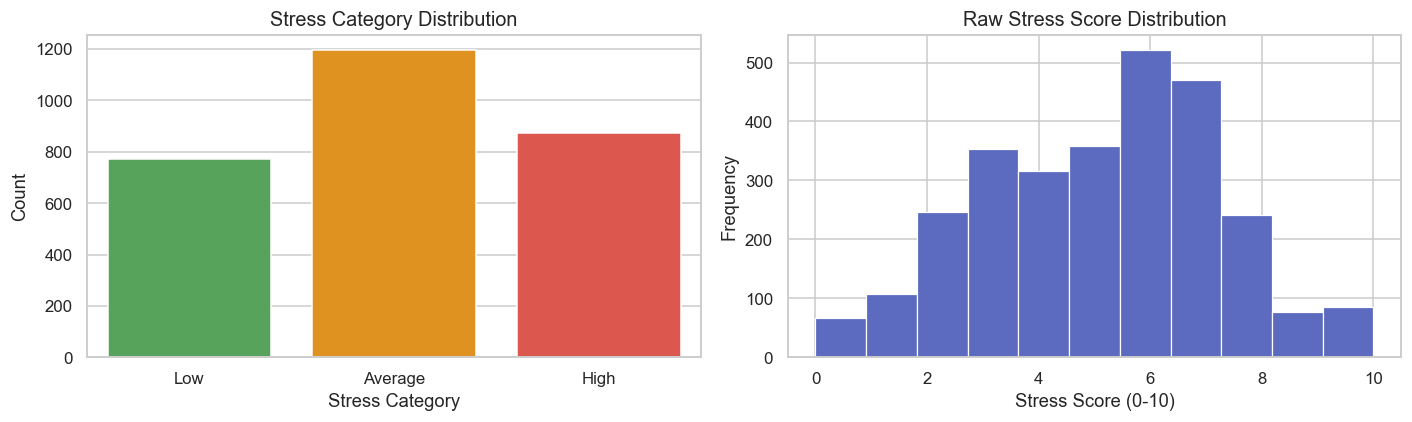

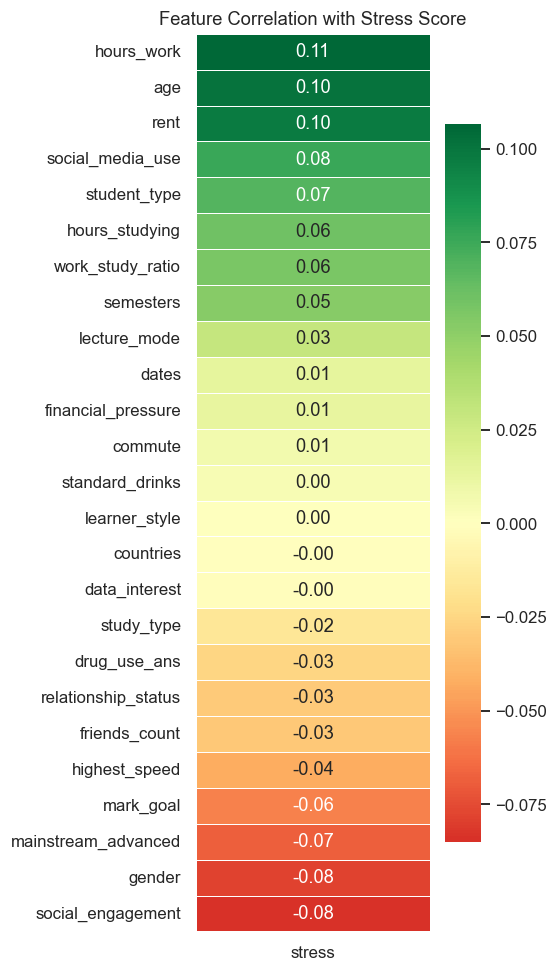

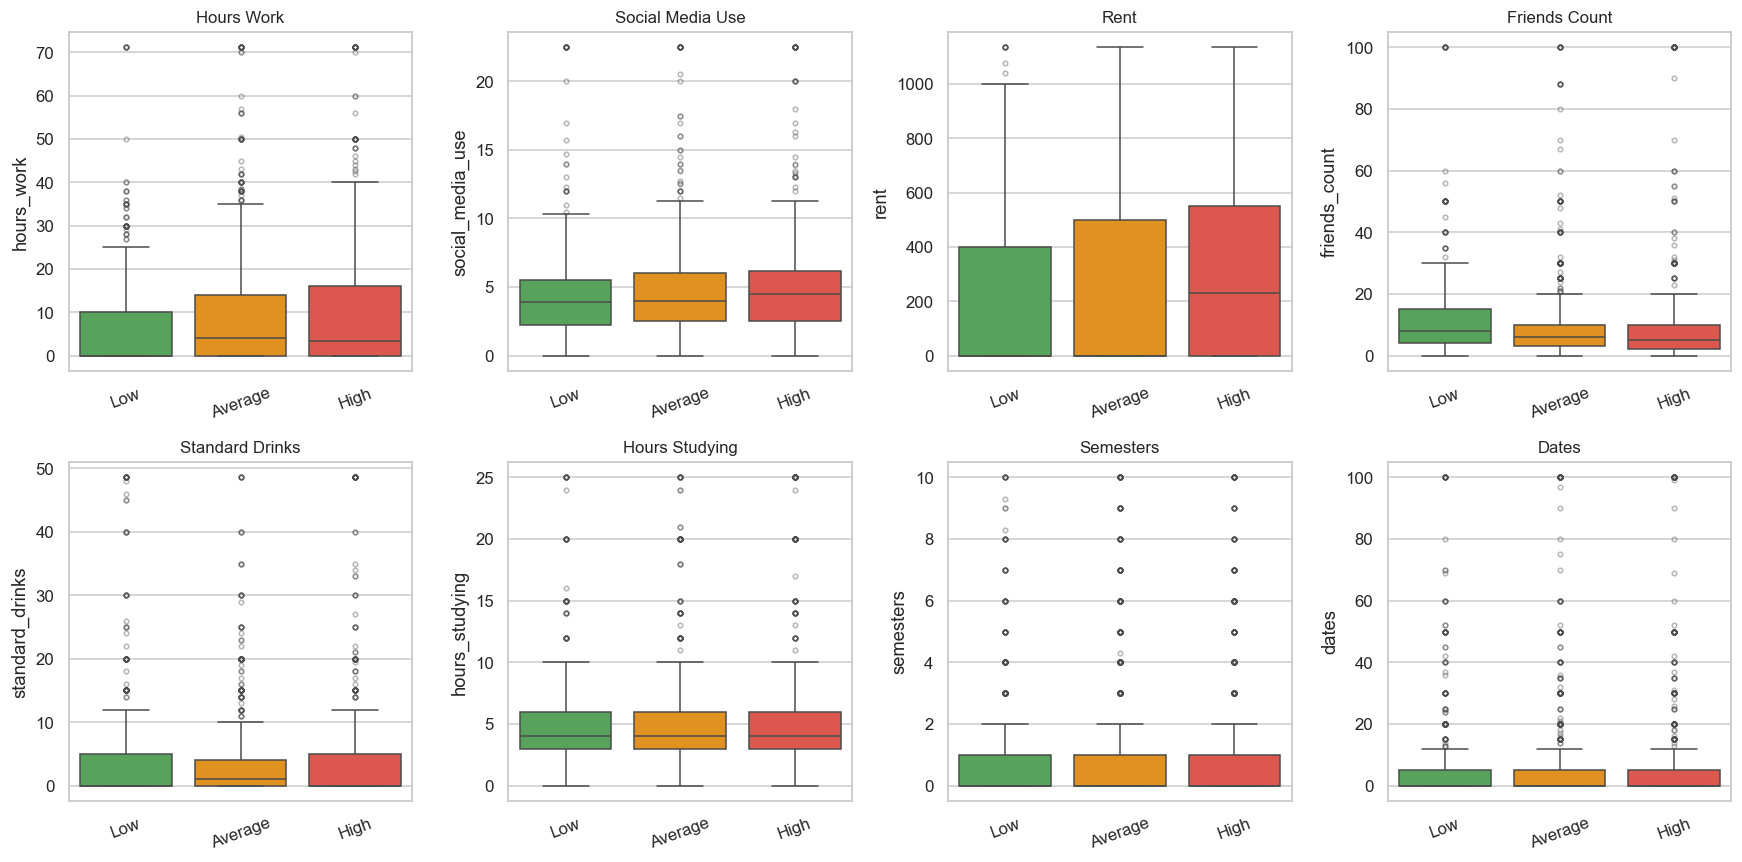

In [28]:
feature_cols = config.NUMERIC_COLS + config.DERIVED_COLS + config.CATEGORICAL_COLS
eda.run(df, df_eda, feature_cols, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

In [29]:
# 5) Split and preprocess (80 train / 20 test)
X_num = df[config.ALL_NUMERIC].copy()
X_cat = raw.loc[df.index, config.ALL_CATS].fillna("Unknown")
X_raw = pd.concat([X_num, X_cat], axis=1)

y_cat = df[config.TARGET_CATEGORY]

X_train, X_test, ycat_train, ycat_test = train_test_split(
    X_raw,
    y_cat,
    test_size=config.TEST_SIZE,
    random_state=config.SEED,
    stratify=y_cat,
)

X_train_t = pipeliner.fit_transform(X_train)
X_test_t = pipeliner.transform(X_test)

print(f"Train={len(X_train_t)} | Test={len(X_test_t)}")

Train=2273 | Test=569


In [30]:
# 6) Train models
for model in models:
    model.train(X_train_t, ycat_train.values)
    print(f"Trained: {model.get_name()}")

Trained: Logistic Regression
Trained: Neural Network
Trained: Gradient Boosting



  Logistic Regression  |  Accuracy: 42.9%
              precision    recall  f1-score   support

         Low       0.44      0.26      0.33       155
     Average       0.44      0.67      0.53       239
        High       0.40      0.25      0.30       175

    accuracy                           0.43       569
   macro avg       0.42      0.39      0.39       569
weighted avg       0.42      0.43      0.40       569


  Neural Network  |  Accuracy: 36.4%
              precision    recall  f1-score   support

         Low       0.31      0.30      0.30       155
     Average       0.42      0.43      0.42       239
        High       0.34      0.34      0.34       175

    accuracy                           0.36       569
   macro avg       0.35      0.35      0.35       569
weighted avg       0.36      0.36      0.36       569


  Gradient Boosting  |  Accuracy: 41.3%
              precision    recall  f1-score   support

         Low       0.39      0.30      0.34       155
     Av

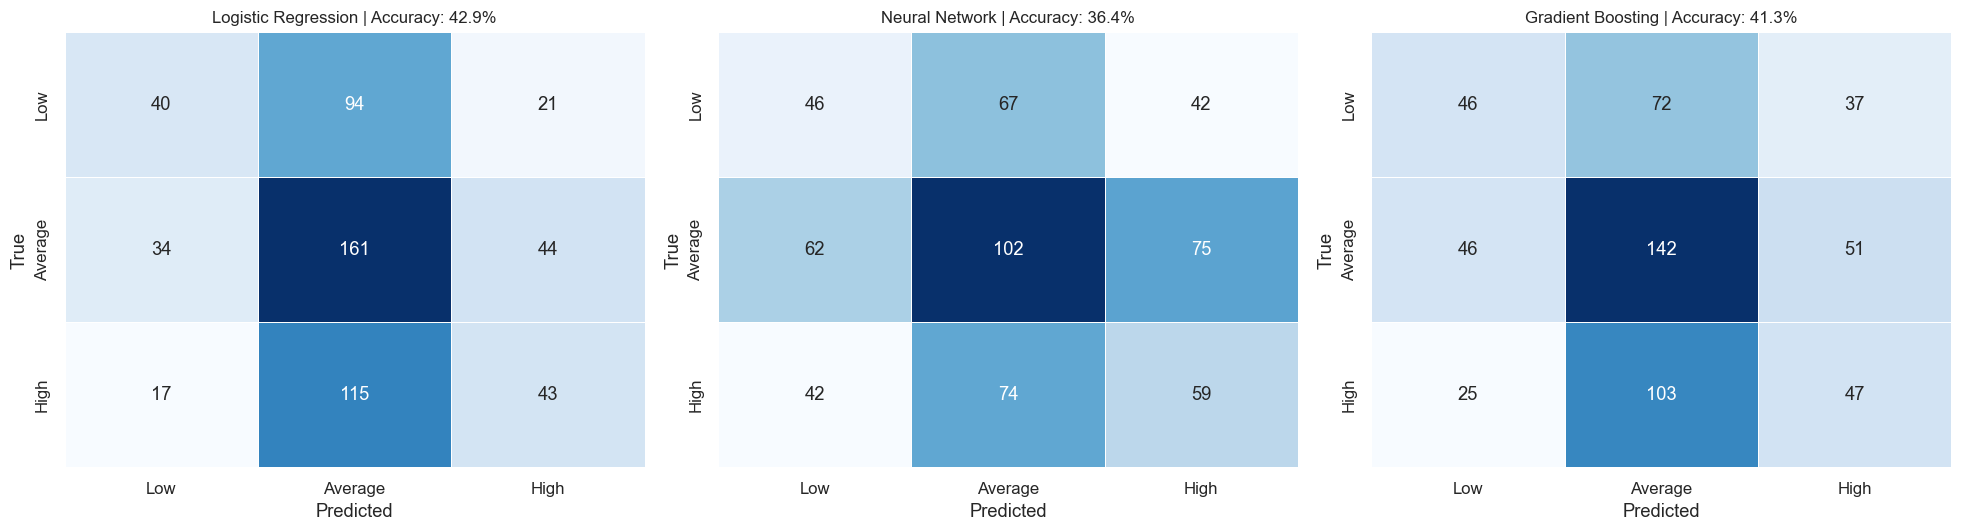

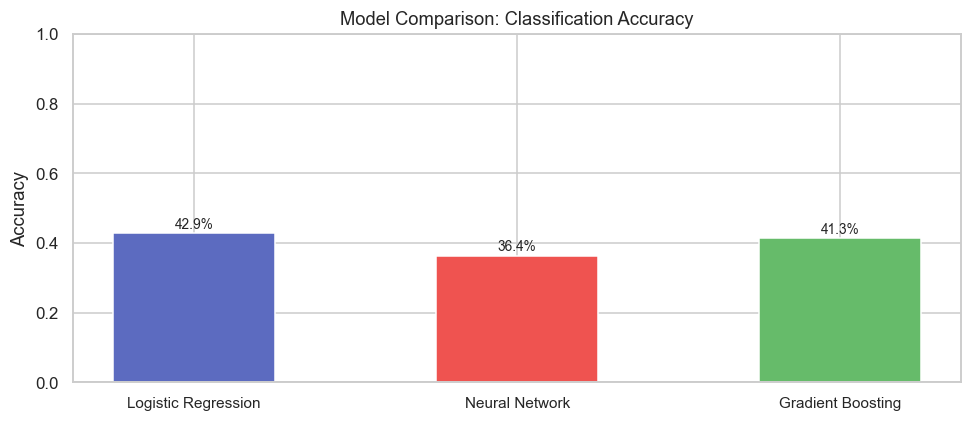

In [31]:
# 7) Evaluate
pred_cats = {m.get_name(): m.predict(X_test_t) for m in models}

class_reports = evaluator.classification_report_all(ycat_test.values, pred_cats, config.CATEGORY_ORDER)
evaluator.print_classification_reports(class_reports)

model_names = list(class_reports.keys())
accs = [class_reports[n]["accuracy"] for n in model_names]
visualizer.plot_confusion_matrices(class_reports, config.CATEGORY_ORDER)
visualizer.plot_model_comparison(model_names, accs)

In [32]:
# 8) Save artifacts
config.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
for model in models:
    model.save(config.SAVED_MODELS_DIR / config.MODEL_FILE_MAP[model.get_name()])
pipeliner.save(config.PIPERLINER_FILE)
print("Saved models and pipeliner.")

Saved models and pipeliner.


In [33]:
# 9) Generate profile and predict
generated_profile = profile_generator.generate_profile(df, seed=config.SEED, mode="random")
profile_df = profile_generator.build(generated_profile)
results = predictor.predict(profile_df, models, pipeliner)
predictor.print_results(results)
results

  STUDENT STRESS PREDICTION
  Logistic Regression   : High
  Neural Network        : High
  Gradient Boosting     : Average


[{'model_name': 'Logistic Regression', 'category': 'High'},
 {'model_name': 'Neural Network', 'category': 'High'},
 {'model_name': 'Gradient Boosting', 'category': 'Average'}]

In [ ]:
Test